# IE 7615 - Discriminative Deep Learning: Milestone 3
**Team:** Rithika Sankar Rajeswari, Sreevarshan Sathiyamurthy, Meena Periasamy, Sahil Mohanty

**Spring 2026 | Northeastern University**

---

This notebook demonstrates:
- **Part A:** Given an image of a single object, the model identifies it
- **Part B:** Given an image of multiple objects, the model identifies and locates all of them

## Step 1: Load Libraries and Models
Run this cell first. It loads both trained models into memory.

In [1]:
import io
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths - automatically finds models relative to this notebook
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'milestone3' else NOTEBOOK_DIR
M1_MODEL  = PROJECT_ROOT / 'milestone1' / 'models' / 'MobileNetV2.keras'
M2_MODEL  = PROJECT_ROOT / 'milestone2' / 'models' / 'yolo_best.pt'
DATA_TRAIN = PROJECT_ROOT / 'milestone1' / 'data' / 'train'

# Load class names
if DATA_TRAIN.exists():
    CLASS_NAMES = sorted([f.name for f in DATA_TRAIN.iterdir() if f.is_dir()])
else:
    CLASS_NAMES = [f'OBJ{str(i).zfill(3)}' for i in range(35)]

# Load models
print('Loading MobileNetV2 classifier...')
classifier = tf.keras.models.load_model(str(M1_MODEL))
print('MobileNetV2 loaded!')

print('Loading YOLOv8 detector...')
detector = YOLO(str(M2_MODEL))
print('YOLOv8 loaded!')

print(f'\nReady! {len(CLASS_NAMES)} classes loaded.')
print('Classes:', CLASS_NAMES)

Loading MobileNetV2 classifier...
MobileNetV2 loaded!
Loading YOLOv8 detector...
YOLOv8 loaded!

Ready! 35 classes loaded.
Classes: ['OBJ001', 'OBJ002', 'OBJ003', 'OBJ004', 'OBJ005', 'OBJ006', 'OBJ007', 'OBJ008', 'OBJ009', 'OBJ010', 'OBJ012', 'OBJ016', 'OBJ018', 'OBJ019', 'OBJ021', 'OBJ022', 'OBJ027', 'OBJ028', 'OBJ029', 'OBJ031', 'OBJ061', 'OBJ090', 'OBJ095', 'OBJ107', 'OBJ108', 'OBJ111', 'OBJ159', 'OBJ208', 'OBJ222', 'OBJ229', 'OBJ230', 'OBJ300', 'OBJ311', 'OBJ405', 'OBJ787']


---
## PART A: Single Object Classification
**Requirement:** Given an image of a single object, the model can ID it.

**How to use:** Replace the image path below with your image, then run the cell.

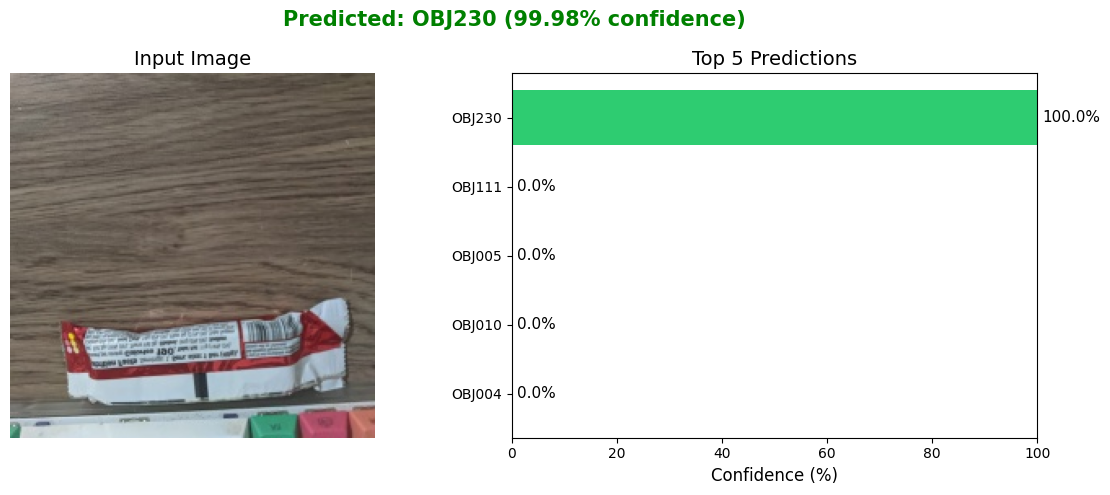


Full Results:
  1. OBJ230       99.98%
  2. OBJ111       0.01%
  3. OBJ005       0.00%
  4. OBJ010       0.00%
  5. OBJ004       0.00%


In [2]:
# -------------------------------------------------------
# CHANGE THIS to the path of your single object image
# Example: '/Users/meena/Desktop/my_object.jpg'
IMAGE_PATH = '/Users/meenaperiasamy/Downloads/discriminative-deep-learning-project/milestone1/data/test/OBJ230/PXL_20260130_161342073.MP_aug0(1).jpg'
# -------------------------------------------------------

# Load and preprocess image
img = Image.open(IMAGE_PATH).convert('RGB')
img_resized = img.resize((224, 224))
arr = np.array(img_resized, dtype=np.float32) / 255.0
arr = np.expand_dims(arr, axis=0)

# Run prediction
preds    = classifier.predict(arr, verbose=0)[0]
top5_idx = np.argsort(preds)[::-1][:5]

# Show image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(img)
ax1.set_title('Input Image', fontsize=14)
ax1.axis('off')

# Show bar chart of top 5 predictions
names = [CLASS_NAMES[i] for i in top5_idx]
confs = [preds[i] * 100 for i in top5_idx]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]

bars = ax2.barh(names[::-1], confs[::-1], color=colors[::-1])
ax2.set_xlabel('Confidence (%)', fontsize=12)
ax2.set_title('Top 5 Predictions', fontsize=14)
ax2.set_xlim(0, 100)

for bar, conf in zip(bars, confs[::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{conf:.1f}%', va='center', fontsize=11)

plt.suptitle(f'Predicted: {CLASS_NAMES[top5_idx[0]]} ({preds[top5_idx[0]]:.2%} confidence)',
             fontsize=15, fontweight='bold', color='green')
plt.tight_layout()
plt.show()

print('\nFull Results:')
for rank, idx in enumerate(top5_idx, 1):
    print(f'  {rank}. {CLASS_NAMES[idx]:<12} {preds[idx]:.2%}')

---
## PART B: Multi-Object Detection and Localization
**Requirement:** Given an image of multiple objects, the model can ID and locate all objects.

**How to use:** Replace the image path below with your multi-object image, then run the cell.

Detected 4 object(s):

  [1] Object ID  : OBJ016
       Confidence : 99.56%
       Location   : x1=31, y1=111, x2=255, y2=335

  [2] Object ID  : OBJ008
       Confidence : 99.11%
       Location   : x1=288, y1=29, x2=512, y2=253

  [3] Object ID  : OBJ111
       Confidence : 98.82%
       Location   : x1=298, y1=332, x2=522, y2=557

  [4] Object ID  : OBJ001
       Confidence : 92.97%
       Location   : x1=36, y1=374, x2=259, y2=601



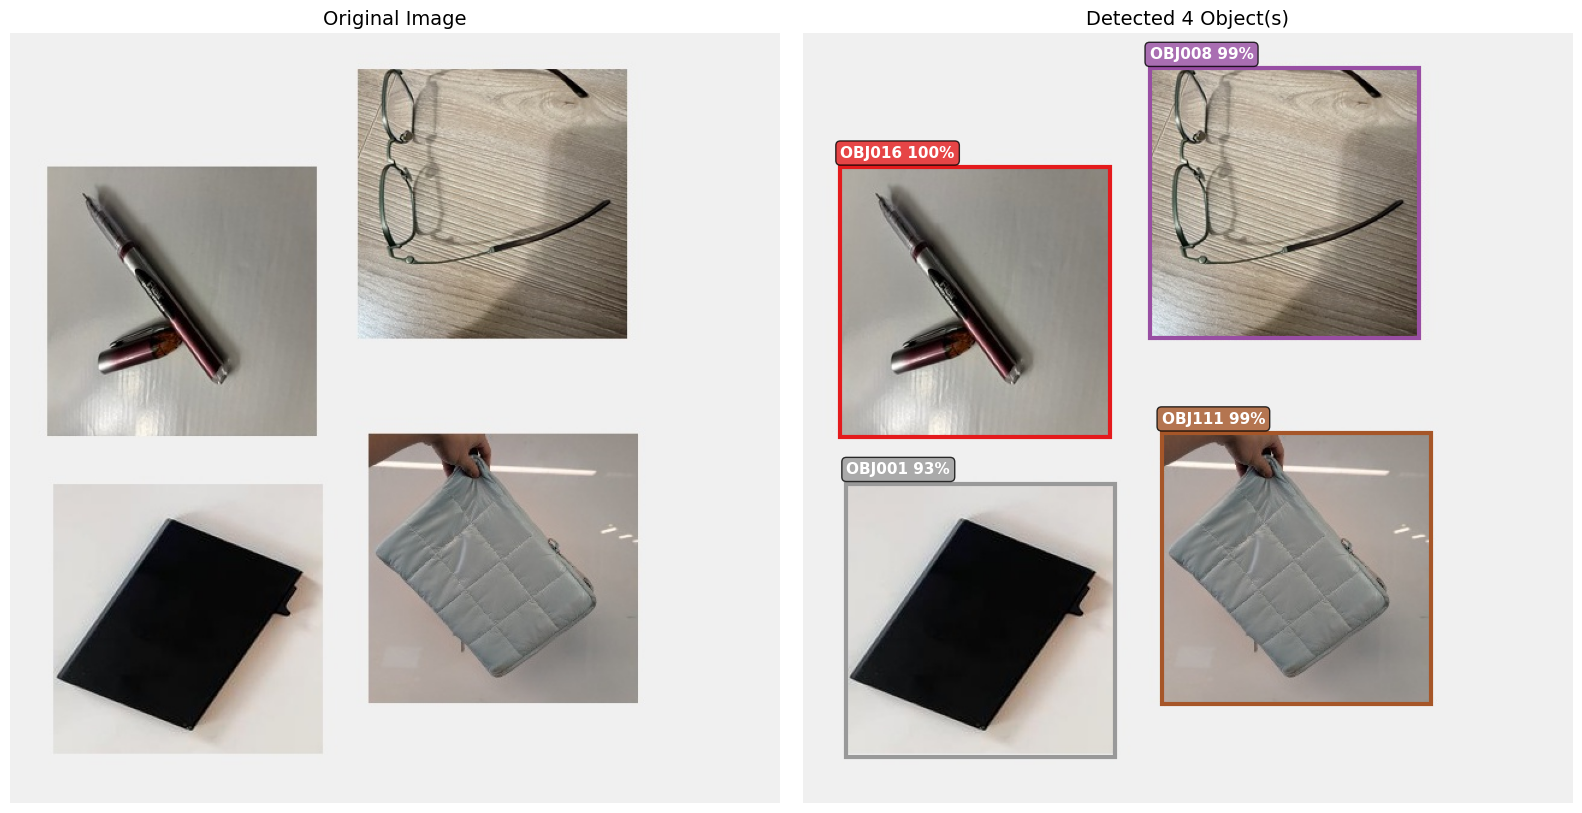

Result saved to milestone3/detection_result.png


In [3]:
# -------------------------------------------------------
# CHANGE THIS to the path of your multi-object image
# Example: '/Users/meena/Desktop/multi_objects.jpg'
IMAGE_PATH = '/Users/meenaperiasamy/Downloads/multi_train_0301.jpg'

# -------------------------------------------------------

# Load image
img = Image.open(IMAGE_PATH).convert('RGB')

# Run YOLOv8 detection
results = detector(img, conf=0.40, iou=0.45, verbose=False)
result  = results[0]
boxes   = result.boxes

# Draw bounding boxes manually for clear visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left: original image
ax1.imshow(img)
ax1.set_title('Original Image', fontsize=14)
ax1.axis('off')

# Right: annotated image with boxes
ax2.imshow(img)
ax2.set_title(f'Detected {len(boxes)} Object(s)', fontsize=14)
ax2.axis('off')

colors = plt.cm.Set1(np.linspace(0, 1, max(len(boxes), 1)))

print(f'Detected {len(boxes)} object(s):\n')

for i, (box, color) in enumerate(zip(boxes, colors), 1):
    cls_id   = int(box.cls[0])
    conf     = float(box.conf[0])
    xyxy     = box.xyxy[0].cpu().numpy().astype(int)
    cls_name = detector.names[cls_id]
    x1, y1, x2, y2 = xyxy

    # Draw box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=3, edgecolor=color, facecolor='none')
    ax2.add_patch(rect)

    # Draw label
    ax2.text(x1, y1 - 8, f'{cls_name} {conf:.0%}',
             color='white', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8))

    print(f'  [{i}] Object ID  : {cls_name}')
    print(f'       Confidence : {conf:.2%}')
    print(f'       Location   : x1={x1}, y1={y1}, x2={x2}, y2={y2}')
    print()

plt.tight_layout()
plt.savefig('/Users/meenaperiasamy/Downloads/detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Result saved to milestone3/detection_result.png')

## PART B (Alernative): Multi-Object Detection and Localization

In [4]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

# File picker button
upload = widgets.FileUpload(accept='image/*', multiple=False)
run_button = widgets.Button(description='Detect Objects', button_style='success')
output = widgets.Output()

def on_run_clicked(b):
    with output:
        clear_output()
        if not upload.value:
            print("Please upload an image first!")
            return
        
        # Get uploaded image
        uploaded_file = list(upload.value)[0]
        img = Image.open(io.BytesIO(uploaded_file.content)).convert('RGB')
        
        # Run detection
        results = detector(img, conf=0.40, iou=0.45, verbose=False)
        result  = results[0]
        boxes   = result.boxes

        # Draw and show
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        ax1.imshow(img)
        ax1.set_title('Original Image', fontsize=14)
        ax1.axis('off')
        ax2.imshow(img)
        ax2.set_title(f'Detected {len(boxes)} Object(s)', fontsize=14)
        ax2.axis('off')
        colors = plt.cm.Set1(np.linspace(0, 1, max(len(boxes), 1)))
        for i, (box, color) in enumerate(zip(boxes, colors), 1):
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            xyxy     = box.xyxy[0].cpu().numpy().astype(int)
            cls_name = detector.names[cls_id]
            x1, y1, x2, y2 = xyxy
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=3, edgecolor=color, facecolor='none')
            ax2.add_patch(rect)
            ax2.text(x1, y1-8, f'{cls_name} {conf:.0%}', color='white',
                     fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8))
            print(f'[{i}] {cls_name} — {conf:.2%} — x1={x1}, y1={y1}, x2={x2}, y2={y2}')
        plt.tight_layout()
        plt.show()

run_button.on_click(on_run_clicked)
display(widgets.VBox([upload, run_button, output]))

---
## Summary

| Requirement | Model Used | Result |
|-------------|-----------|--------|
| Single object ID | MobileNetV2 | 98.94% accuracy |
| Multi-object ID + locate | YOLOv8s | 93.52% mAP@0.5 |